In [1]:
%matplotlib inline

import os
import warnings
import gc

os.environ['OPENCV_LOG_LEVEL'] = 'ERROR'

import albumentations as A
import numpy as np
from albumentations.pytorch import ToTensorV2
import cv2
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR,OneCycleLR
from torchmetrics.classification import JaccardIndex
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy
from torchmetrics import Accuracy
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from skimage.morphology import binary_closing, disk
from monai.inferers import SlidingWindowInferer

/home/a.pozdnyakov/AI-labs/myvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
image_size = 512
train_transform = A.Compose([
    # A.RandomResizedCrop(size=(image_size, image_size), scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    A.RandomCrop(height=image_size, width=image_size, always_apply=True),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),  # ← Спутниковые снимки не имеют "верха"
    A.Rotate(limit=25, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
    
    # Цветовые изменения (сезона, время суток, разные спутники)
    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0),
        A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=1.0),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=15, p=1.0),
    ], p=0.7),
    
    # Погодные условия
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),  # ← Размытие от движения спутника
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    
    # Геометрические искажения
    # A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.4),
    # A.OpticalDistortion(distort_limit=0.3, p=0.3),
    # A.ElasticTransform(alpha=1, sigma=30, alpha_affine=30, p=0.2),
    
    # Dropout аугментации (помогает от переобучения)
    A.GridDropout(ratio=0.2, unit_size_range=(10, 50), shift_xy=(10, 10), random_offset=True, p=0.3),
    
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

val_transform = A.Compose([
    A.CenterCrop(height=image_size, width=image_size, always_apply=True),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

test_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/tmp/ipykernel_58928/2060554360.py:4: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomCrop
  A.RandomCrop(height=image_size, width=image_size, always_apply=True),
/tmp/ipykernel_58928/2060554360.py:8: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=25, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
/tmp/ipykernel_58928/2060554360.py:19: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
/tmp/ipykernel_58928/2060554360.py:36: UserWarning: Argument(s) 'always_apply' are not valid for transform CenterCrop
  A.CenterCrop(height=image_size, width=image_size, always_apply=True),


In [3]:
class SegDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None):
        self.image_paths = image_paths
        self.label_paths = label_paths

        self.image_filenames = sorted(os.listdir(image_paths))
        self.label_filenames = sorted(os.listdir(label_paths))

        self.transform = transform

    def __getitem__(self, idx):
        image = cv2.imread(f'{self.image_paths}/{self.image_filenames[idx]}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(f'{self.label_paths}/{self.label_filenames[idx]}', cv2.IMREAD_GRAYSCALE)
        mask = mask / 255.0
        # mask = mask.astype(np.uint8)

        if self.transform:
            sample = self.transform(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        mask = mask.unsqueeze(0).float()
        return image, mask

    def __len__(self):
        return len(self.image_filenames)

In [4]:
class BCEAndDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction='mean')
        self.dice = smp.losses.DiceLoss(mode='binary')

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        bce_loss = bce_loss * self.bce_weight

        dice_loss = self.dice(torch.sigmoid(pred), target) * self.dice_weight

        return bce_loss + dice_loss
class FocalIoULoss(nn.Module):
    def __init__(self, focal_weight=0.5, iou_weight=0.5, gamma=2.0):
        super().__init__()
        
        self.focal = smp.losses.FocalLoss(
            mode='binary', 
            gamma=gamma, 
            alpha=0.25, 
            normalized=True
        )
        
        self.iou = smp.losses.JaccardLoss(mode='binary')
        
        self.focal_weight = focal_weight
        self.iou_weight = iou_weight

    def forward(self, pred, target):
        focal_loss = self.focal(pred, target) * self.focal_weight
        iou_loss = self.iou(pred, target) * self.iou_weight
        
        return focal_loss + iou_loss

In [5]:
def calculate_dice(pred, target, threshold=0.5, smooth=1e-6):
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice

In [6]:
def create_loaders():
    batch_size = 24
    train_dataset = SegDataset("tiff/train","tiff/train_labels",transform=train_transform)
    val_dataset = SegDataset("tiff/val","tiff/val_labels",transform=val_transform)
    test_dataset = SegDataset("tiff/test","tiff/test_labels",transform=test_transform)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=16, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, num_workers=16, pin_memory=True, persistent_workers=True)
    # test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, num_workers=16, pin_memory=True, persistent_workers=True)

    return train_loader, val_loader

In [7]:
def create_model():
    model = smp.UnetPlusPlus(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )
    model = model.to(device)
    model = torch.nn.DataParallel(model)

    for param in model.module.encoder.parameters():
        param.requires_grad = False

    return model

def create_model_for_inference():
    model = smp.UnetPlusPlus(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )
    model = model.to(device)
    return model

In [8]:
def train(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs, best_iou, number,threshold):
    best_val_iou = best_iou
    patience_counter = 0

    train_losses = []
    val_losses = []

    iou_metric = BinaryJaccardIndex(threshold=threshold).to(device)
    acc_metric = BinaryAccuracy(threshold=threshold).to(device)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_idx, (img, label) in enumerate(train_loader):
            img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)
            if epoch == 0 and batch_idx == 0:
                print(f"Min/Max Label: {label.min():.4f}, {label.max():.4f}")
                print(f"Unique Label Values: {torch.unique(label)}")
                    
            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()
            if number == 1:
                scheduler.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        dice_total = 0
        with torch.no_grad():
            val_loss = 0
            has_objects = False
            for img, label in val_loader:
                img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)
                output = model(img)
                loss = criterion(output, label)
                val_loss += loss.item()
                output=torch.sigmoid(output)

                if epoch == 0 and not has_objects:
                    print(f"\n[DEBUG] Label sum: {label.sum().item()}") # Сколько пикселей объекта в маске
                    print(f"[DEBUG] Label unique: {torch.unique(label)}")
                    print(f"[DEBUG] Pred min/max: {output.min():.4f} / {output.max():.4f}")
                    
                    if label.sum() > 0:
                        has_objects = True
                        print(">>> В масках ЕСТЬ объекты!")
                    else:
                        print(">>> В масках НЕТ объектов (только фон)!")
                
                dice_total += calculate_dice(output, label)
                iou_metric.update(output, label)
                acc_metric.update(output, label)

            val_loss /= len(val_loader)
            val_losses.append(val_loss)
            dice = dice_total / len(val_loader)
            iou = iou_metric.compute()
            acc = acc_metric.compute()

            iou_metric.reset()
            acc_metric.reset()
            if number == 2:
                scheduler.step()
            print(f"epoch: {epoch}\n val loss: {val_loss:.4f}\ndice: {dice:.4f}\niou: {iou:.4f}\nacc: {acc:.4f}\n")
            if iou > best_val_iou:
                best_val_iou = iou
                patience_counter = 0
                state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
                torch.save(state_dict, 'model.pth')
                print("модель обновлена")
            else:
                patience_counter += 1
                if patience_counter == 10:
                    break

    return train_losses, val_losses, best_val_iou


In [9]:
def post_process(mask_np, threshold=0.5):
    binary = (mask_np > threshold).astype(np.uint8)
    # Ядро 3x3 или 5x5 помогает соединить разрывы
    kernel = disk(2)
    cleaned = binary_closing(binary, kernel)
    return cleaned.astype(np.float32)
# def test(test_loader, criterion):

#     model = create_model_for_inference()
#     checkpoint = torch.load('model.pth', map_location=device)
#     model.load_state_dict(checkpoint)
    
#     iou_metric = BinaryJaccardIndex(threshold=0.74).to(device)
#     acc_metric = BinaryAccuracy(threshold=0.5).to(device)

#     dice_total = 0
    
#     with torch.no_grad():
#         model.eval()
#         test_loss = 0
#         for img, label in test_loader:
#             img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)
#             output = model(img)
#             loss = criterion(output, label)

#             output=torch.sigmoid(output)

#             output_np = output.cpu().numpy()
#             processed_masks = []
#             for m in output_np:
#                 pm = post_process(m[0], 0.5)
#                 processed_masks.append(pm)

#             output_tensor = torch.tensor(np.array(processed_masks)).unsqueeze(1).to(device)

#             dice_total += calculate_dice(output_tensor, label)
#             iou_metric.update(output_tensor, label)
#             acc_metric.update(output_tensor, label)
#             test_loss += loss.item()

#         test_loss /= len(test_loader)
#         dice = dice_total / len(test_loader)
#         iou = iou_metric.compute()
#         acc = acc_metric.compute()

#         iou_metric.reset()
#         acc_metric.reset()

#         print(f"test loss: {test_loss:.4f}\ndice: {dice:.4f}\niou: {iou:.4f}\nacc: {acc:.4f}")


def test(image_dir, mask_dir, threshold, inferer):
    model = create_model_for_inference()
    checkpoint = torch.load('model.pth', map_location=device)
    model.load_state_dict(checkpoint)
    model.eval()
    
    iou_metric = BinaryJaccardIndex(threshold=threshold).to(device)
    acc_metric = BinaryAccuracy(threshold=threshold).to(device)

    dice_total = 0
    
    with torch.no_grad():
        for fname in os.listdir(image_dir):
            img_path = os.path.join(image_dir, fname)
            mask_path = os.path.join(mask_dir, fname.replace('.tiff', '.tif'))
            
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 128).astype(np.float32)

            sample = test_transform(image=img, mask=mask)
            img, mask = sample['image'].to(device), sample['mask'].unsqueeze(0).unsqueeze(0).to(device)
            
            output = inferer(inputs=img.unsqueeze(0), network=model)
            
            output=torch.sigmoid(output)
            
            # 5. Метрики
            dice_total += calculate_dice(output, mask)
            iou_metric.update(output, mask)
            acc_metric.update(output, mask)
            
            
    print("\n📈 Итоговые метрики:")
    print(f"Dice: {dice_total/len(os.listdir(image_dir)):.4f}")
    print(f"IoU : {iou_metric.compute().item():.4f}")
    print(f"Acc : {acc_metric.compute().item():.4f}")
    
    iou_metric.reset()
    acc_metric.reset()

In [10]:
def train_graph(epochs, train_loss, val_loss):
    plt.figure(figsize=(10,5))

    plt.plot(epochs, train_loss, color="green", label="train loss")
    plt.plot(epochs, val_loss, color="red", label="val loss")

    plt.xlabel("эпоха")
    plt.ylabel("loss")
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.show()

In [11]:
def find_optimal_threshold(val_loader, inferer, step=0.01):
    model = create_model_for_inference().to(device)
    model.load_state_dict(torch.load('model.pth', map_location=device))
    model.eval()
    
    thresholds = np.arange(0.1, 0.9 + step, step)
    metrics = {t: 0.0 for t in thresholds}
    
    # Создаём метрику ОДИН РАЗ (ускоряет работу в 10-20 раз)
    iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
    
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)
            
            # 1. УБРАЛИ .unsqueeze(0) — loader уже отдаёт [B, C, H, W]
            prob = torch.sigmoid(inferer(inputs=img, network=model))  # [B, 1, H, W]
            
            # 2. Приводим маску к той же форме [B, 1, H, W]
            if mask.dim() == 3:
                mask = mask.unsqueeze(1)
                
            for t in thresholds:
                pred_bin = (prob > t).float()  # [B, 1, H, W]
                
                iou_metric.update(pred_bin, mask)
                metrics[t] += iou_metric.compute().item()
                iou_metric.reset()
                
    n = len(val_loader)
    metrics = {t: v / n for t, v in metrics.items()}
    
    best_t = max(metrics, key=metrics.get)
    print(f"🏆 Лучший threshold для IoU: {best_t:.2f} (метрика: {metrics[best_t]:.4f})")
    return best_t

In [12]:
def main():
    train_loader, val_loader = create_loaders()
    model = create_model()
    # criterion = BCEAndDiceLoss()
    criterion = FocalIoULoss(focal_weight=0.30, iou_weight=0.70, gamma=2.0)

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.module.parameters()), lr=1e-3)
    # scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-6)
    scheduler = OneCycleLR(
        optimizer, 
        max_lr=1e-3,          # Максимальный LR (пик)
        epochs=50,            # Количество эпох
        steps_per_epoch=len(train_loader),
        pct_start=0.15,        # 10% времени на разгон, 90% на снижение
        anneal_strategy='cos' # Косинусное снижение
    )
    train_loss1, val_loss1, best_iou = train(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs=50, best_iou=0, number=1, threshold=0.5)

    if hasattr(model, 'module'):
        del model.module
    
    del model, optimizer, scheduler
    gc.collect()
    del train_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()

    train_loader, val_loader = create_loaders()
    
    model = create_model()
    checkpoint = torch.load('model.pth', map_location=device)
    model.module.load_state_dict(checkpoint)
    del checkpoint
    for param in model.module.encoder.parameters():
        param.requires_grad = True
    optimizer = torch.optim.AdamW(model.module.parameters(), lr=1e-4)
    # scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-6)
    scheduler = CosineAnnealingLR(
        optimizer, 
        T_max=50,           # Максимум эпох
        eta_min=1e-7        # Минимальный LR
    )
    train_loss2, val_loss2, _ = train(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs=50, best_iou=best_iou, number=2, threshold=0.5)

    if hasattr(model, 'module'):
        del model.module
    
    del optimizer, scheduler, model, train_loader
    gc.collect()
    torch.cuda.empty_cache()

    inferer = SlidingWindowInferer(
        roi_size=(512, 512),
        sw_batch_size=8,
        overlap=0.55,
        mode="gaussian",  # обязательно для дорог
        padding_mode="constant"
    )
    
    threshold = find_optimal_threshold(val_loader, inferer)
    
    train_graph(list(range(len(train_loss1+train_loss2))), train_loss1+train_loss2, val_loss1+val_loss2)
    test("tiff/test","tiff/test_labels", threshold, inferer)

Min/Max Label: 0.0000, 1.0000
Unique Label Values: tensor([0., 1.], device='cuda:0')

[DEBUG] Label sum: 243056.0
[DEBUG] Label unique: tensor([0., 1.], device='cuda:0')
[DEBUG] Pred min/max: 0.0121 / 1.0000
>>> В масках ЕСТЬ объекты!
epoch: 0
 val loss: 0.6002
dice: 0.3212
iou: 0.1913
acc: 0.7410

модель обновлена
epoch: 1
 val loss: 0.6250
dice: 0.2095
iou: 0.1170
acc: 0.5031

epoch: 2
 val loss: 0.5410
dice: 0.4490
iou: 0.2895
acc: 0.8513

модель обновлена
epoch: 3
 val loss: 0.4342
dice: 0.6132
iou: 0.4422
acc: 0.9349

модель обновлена
epoch: 4
 val loss: 0.4016
dice: 0.6131
iou: 0.4420
acc: 0.9338

epoch: 5
 val loss: 0.3920
dice: 0.6179
iou: 0.4471
acc: 0.9326

модель обновлена
epoch: 6
 val loss: 0.3710
dice: 0.6440
iou: 0.4749
acc: 0.9492

модель обновлена
epoch: 7
 val loss: 0.5388
dice: 0.3824
iou: 0.2364
acc: 0.7951

epoch: 8
 val loss: 0.3410
dice: 0.6810
iou: 0.5163
acc: 0.9528

модель обновлена
epoch: 9
 val loss: 0.3361
dice: 0.6865
iou: 0.5227
acc: 0.9611

модель обновл

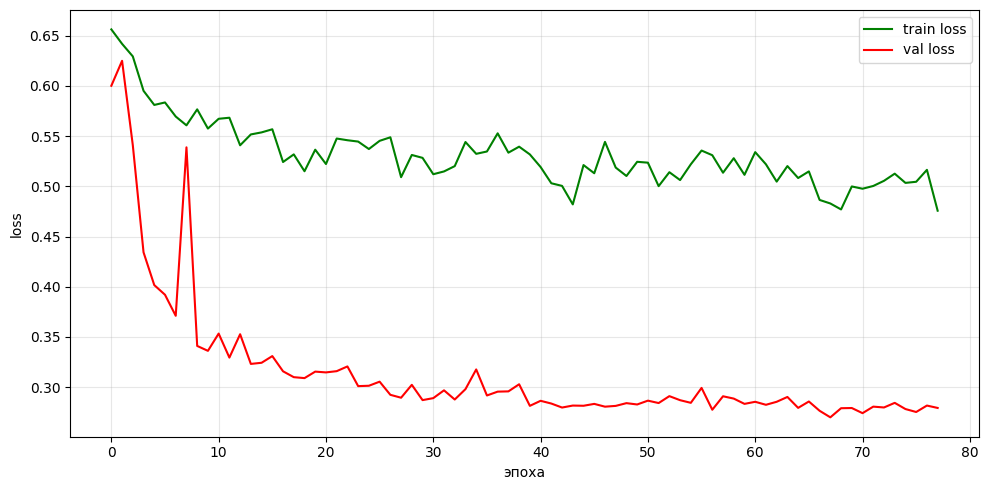

In [13]:
if __name__ == '__main__':
    main()

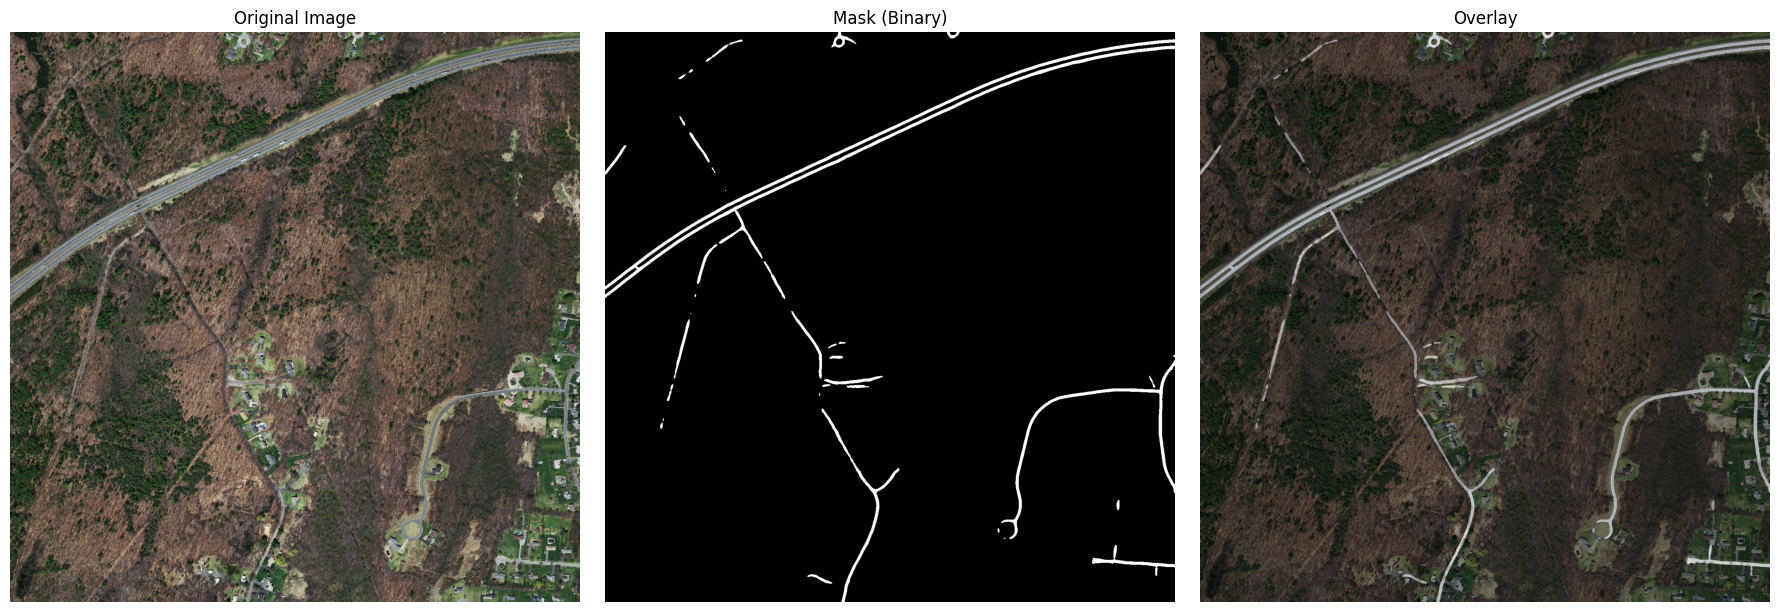

In [14]:
import matplotlib.pyplot as plt
model = create_model_for_inference()
checkpoint = torch.load('model.pth', map_location=device)
model.load_state_dict(checkpoint)
model.eval()

inferer = SlidingWindowInferer(
        roi_size=(512, 512),
        sw_batch_size=8,
        overlap=0.55,
        mode="gaussian",  # обязательно для дорог
        padding_mode="constant"
    )

image = cv2.imread(r'tiff/test/10378780_15.tiff')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sample = test_transform(image=image)
image_tensor = sample['image'].unsqueeze(0).to(device)

with torch.no_grad():
    mask = (torch.sigmoid(inferer(image_tensor, network=model)) > 0.5).float()
    mask = (mask * 255).byte().squeeze(0).squeeze(0)
    mask = mask.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask (Binary)')
axes[1].axis('off')

axes[2].imshow(image)
axes[2].imshow(mask, cmap='gray', alpha=0.4)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [15]:
%matplotlib inline

import os
import warnings

os.environ['OPENCV_LOG_LEVEL'] = 'ERROR'

import albumentations as A
import numpy as np
from albumentations.pytorch import ToTensorV2
import cv2
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
# from torchmetrics.segmentation import DiceScore
from torchmetrics.classification import JaccardIndex
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy
from torchmetrics import Accuracy
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

def calculate_dice(pred, target, threshold=0.5, smooth=1e-6):
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice

train_transform = A.Compose([
    A.RandomResizedCrop(size=(1024, 1024), scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),  # ← Спутниковые снимки не имеют "верха"
    A.Rotate(limit=25, border_mode=cv2.BORDER_REFLECT, p=0.5),
    
    # Цветовые изменения (сезона, время суток, разные спутники)
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.6),
    A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.4),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=15, p=0.4),
    
    # Погодные условия
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),  # ← Размытие от движения спутника
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    
    # Геометрические искажения
    # A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.4),
    # A.OpticalDistortion(distort_limit=0.3, p=0.3),
    # A.ElasticTransform(alpha=1, sigma=30, alpha_affine=30, p=0.2),
    
    # Dropout аугментации (помогает от переобучения)
    A.CoarseDropout(max_holes=8, max_height=50, max_width=50, p=0.3),
    
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

test_transform = A.Compose([
    A.Resize(1024, 1024),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FocalIoULoss(nn.Module):
    def __init__(self, focal_weight=0.3, iou_weight=0.7, gamma=2.0):
        super().__init__()
        
        self.focal = smp.losses.FocalLoss(
            mode='binary', 
            gamma=gamma, 
            alpha=0.25, 
            normalized=True
        )
        
        self.iou = smp.losses.JaccardLoss(mode='binary')
        
        self.focal_weight = focal_weight
        self.iou_weight = iou_weight

    def forward(self, pred, target):
        focal_loss = self.focal(pred, target) * self.focal_weight
        iou_loss = self.iou(pred, target) * self.iou_weight
        
        return focal_loss + iou_loss
        
def create_model_for_inference():
    model = smp.UnetPlusPlus(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )
    model = model.to(device)
    return model

def predict_with_tta(model, image_tensor, device):
    """
    Упрощённый TTA — только Horizontal Flip (самый стабильный)
    """
    model.eval()
    predictions = []
    
    with torch.no_grad():
        # 1. Оригинал
        output = model(image_tensor)
        prob = torch.sigmoid(output)
        predictions.append(prob)
        
        # 2. Horizontal Flip
        img_flip = torch.flip(image_tensor, dims=[3])
        output = model(img_flip)
        prob = torch.sigmoid(output)
        prob = torch.flip(prob, dims=[3])  # Обратный flip
        predictions.append(prob)
    
    # Усреднение
    final_pred = torch.stack(predictions).mean(dim=0)
    return final_pred
    
def test(model, test_loader, criterion, use_tta=False):
    iou_metric = BinaryJaccardIndex(threshold=0.74).to(device)
    acc_metric = BinaryAccuracy(threshold=0.74).to(device)
    dice_total = 0
    
    model.eval()
    test_loss = 0
    
    with torch.no_grad():
        for img, label in test_loader:
            img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)
            
            if use_tta:
                # TTA для каждого изображения в батче
                outputs = []
                for i in range(img.size(0)):
                    pred = predict_with_tta(model, img[i:i+1], device)
                    outputs.append(pred)
                output = torch.cat(outputs, dim=0)  # ← Уже вероятности [0, 1]!
                prob = output  # ← ✅ НЕ применяем sigmoid ещё раз!
            else:
                output = model(img)  # ← Логиты
                prob = torch.sigmoid(output)  # ← ✅ Применяем sigmoid только здесь!
            
            loss = criterion(output, label)
            test_loss += loss.item()
            
            dice_total += calculate_dice(prob, label)
            iou_metric.update(prob, label)
            acc_metric.update(prob, label)
    
    test_loss /= len(test_loader)
    dice = dice_total / len(test_loader)
    iou = iou_metric.compute()
    acc = acc_metric.compute()
    
    print(f"test loss: {test_loss:.4f}\ndice: {dice:.4f}\niou: {iou:.4f}\nacc: {acc:.4f}")
    print(f"TTA: {'Enabled' if use_tta else 'Disabled'}")
    
    return iou.item()

class SegDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None):
        self.image_paths = image_paths
        self.label_paths = label_paths

        self.image_filenames = sorted(os.listdir(image_paths))
        self.label_filenames = sorted(os.listdir(label_paths))

        self.transform = transform

    def __getitem__(self, idx):
        image = cv2.imread(f'{self.image_paths}/{self.image_filenames[idx]}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(f'{self.label_paths}/{self.label_filenames[idx]}', cv2.IMREAD_GRAYSCALE)
        mask = mask.astype(np.float32) / 255.0
        # mask = mask.astype(np.uint8)

        if self.transform:
            sample = self.transform(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        mask = mask.unsqueeze(0).float()
        return image, mask

    def __len__(self):
        return len(self.image_filenames)



def create_loaders():
    train_dataset = SegDataset("tiff/train","tiff/train_labels",transform=train_transform)
    val_dataset = SegDataset("tiff/val","tiff/val_labels",transform=test_transform)
    test_dataset = SegDataset("tiff/test","tiff/test_labels",transform=test_transform)

    train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True, num_workers=16, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=8, num_workers=16, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=8, num_workers=16, pin_memory=True, persistent_workers=True)

    return train_loader, val_loader, test_loader
train_loader, val_loader, test_loader = create_loaders()
model = create_model_for_inference()
checkpoint = torch.load('model.pth', map_location=device)
model.load_state_dict(checkpoint)
criterion = FocalIoULoss(focal_weight=0.2, iou_weight=0.8, gamma=2.0)
test(model, test_loader, criterion)

/tmp/ipykernel_58928/3430004261.py:44: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
/tmp/ipykernel_58928/3430004261.py:54: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=50, max_width=50, p=0.3),


test loss: 0.4083
dice: 0.6574
iou: 0.4862
acc: 0.9618
TTA: Disabled


0.48617827892303467